In [1]:
# This is program:
#1. Takes a stock name as input from the user.
#2. Fetches data from yahoo finance using library name as yfinanace.
#3. Displays : Company Name, Current price, Price change.
#4. Runs in a loop so that mutliple stocks can be checked.



==========Complete Stock Analysis============


Enter the stock symbol (Or 'Quit' to Stop):  TCS.NS



----------------------------
Company: Tata Consultancy Services Limited
Current Price: 2472.6
Change: -51.70 (-2.05%)
-------------------------------



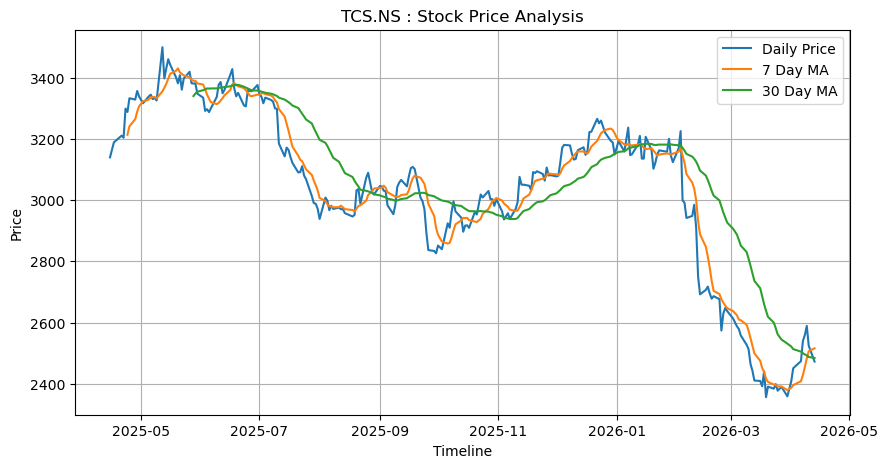

Enter the stock symbol (Or 'Quit' to Stop):  Quit


Exiting Program. Thank you !!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

print("==========Complete Stock Analysis============")

while True:
    symbol = input("Enter the stock symbol (Or 'Quit' to Stop): ").upper()
    if symbol == "QUIT":
        print("Exiting Program. Thank you !!")
        break

    try:
        # Step 2: Get the company info
        stock = yf.Ticker(symbol)
        info = stock.info
        name  = info.get("longName", "N/A")
        price = info.get("currentPrice")
        prev_close = info.get("previousClose")
        currency = info.get("currency")

        print("\n----------------------------")
        print(f"Company: {name}")
        print(f"Current Price: {price}")
        
        # Step 3: Calculate the price change
        if price and prev_close:
            change = price - prev_close
            percent = (change / prev_close) * 100
            print(f"Change: {change:+.2f} ({percent:+.2f}%)")
        else:
            print("Price or Previous close not available.")
        print("-------------------------------")

        # Step 4: Download historical data
        print("Downloading historical data.....\n")
        df = yf.download(symbol, period="12mo", progress=False)

        if df.empty:
            print(f"No historical data found for {symbol}. Skipping chart.")
        else:
            df['7_day_MA'] = df["Close"].rolling(window=7).mean()
            df['30_day_MA'] = df["Close"].rolling(window=30).mean()

            # Step 5: Plot the graph
            plt.figure(figsize=(10,5))
            plt.plot(df['Close'], label="Daily Price")
            plt.plot(df['7_day_MA'], label="7 Day MA")   
            plt.plot(df['30_day_MA'], label="30 Day MA")
            plt.title(f"{symbol} : Stock Price Analysis")
            plt.xlabel("Timeline")
            plt.ylabel("Price")
            plt.legend()
            plt.grid(True)
            plt.show()

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")
